## Titanic Survival Prediction

### 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path().resolve()
train_path = BASE_DIR / "data" / "raw" / "train.csv"
test_path  = BASE_DIR / "data" / "raw" / "test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Exploratory Data Analysis

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
#Missing values in each dataset
print("Train missing values")
print(train_df.isnull().sum())
print()
print("Test missing values")
print(test_df.isnull().sum())

Train missing values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test missing values
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [6]:
#Target class balance
print(train_df["Survived"].value_counts())
print()
print(train_df["Survived"].value_counts(normalize=True).round(3))

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


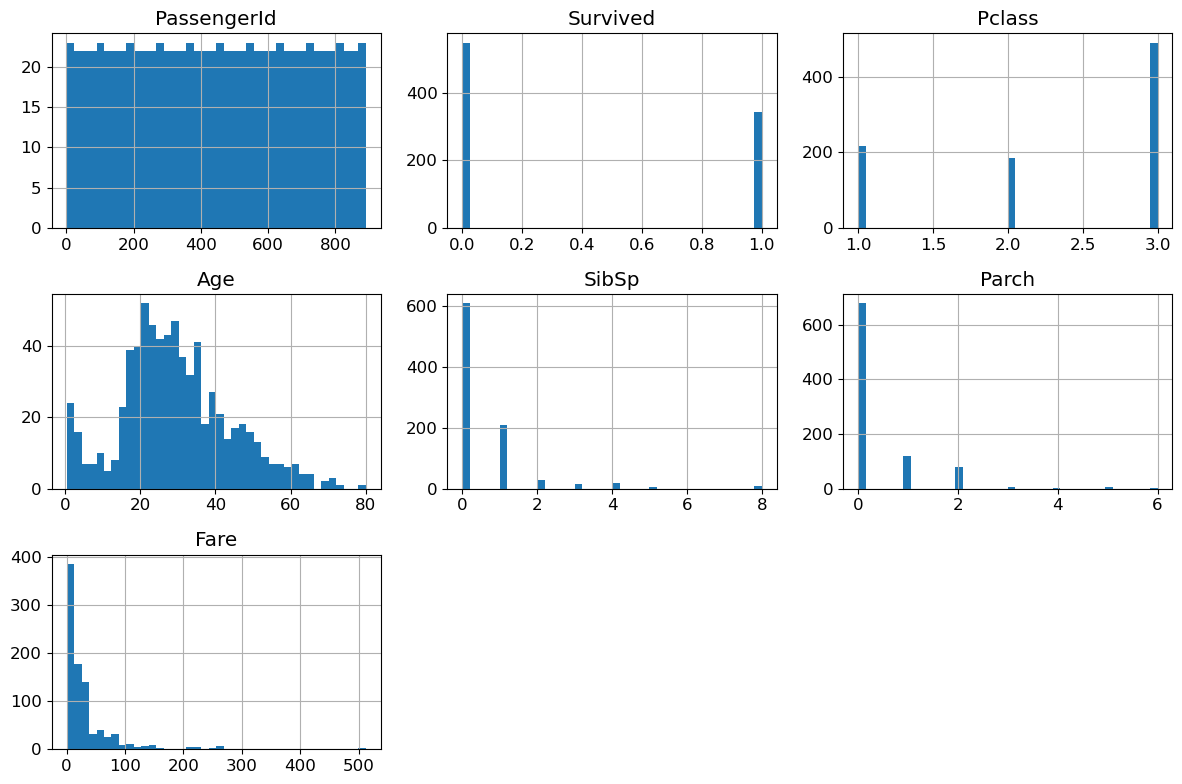

In [7]:
plt.rc('font', size=12)
train_df.hist(bins=40, figsize=(12, 8))
plt.tight_layout()
plt.show()

### 3. Preprocessing & Feature Engineering

**Key rule:** We fit statistics (median, mode, etc.) on the **training set only**, then apply the same values to the test set. This prevents data leakage.

In [8]:
def engineer_features(df, age_median=None, fare_median=None, embarked_mode=None, is_train=True):
    df = df.copy()

    # 1. Compute fill values if training
    if is_train:
        age_median = df["Age"].median()
        fare_median = df["Fare"].median()
        embarked_mode = df["Embarked"].mode()[0]

    # 2. APPLY the fills (This is the part that fixes the ValueError!)
    df["Age"] = df["Age"].fillna(age_median)
    df["Fare"] = df["Fare"].fillna(fare_median)
    df["Embarked"] = df["Embarked"].fillna(embarked_mode)

    # 3. Encode Sex
    df["Sex"] = (df["Sex"] == "female").astype(int)

    # 4. Title extraction
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace(
        ["Lady", "Countess", "Capt", "Col", "Don", "Dr",
         "Major", "Rev", "Sir", "Jonkheer", "Dona"], "Rare")
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

    # 5. Family features
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["FamilyType"] = pd.cut(
        df["FamilySize"],
        bins = [0, 1, 4, 10],
        labels = ["Alone", "Small", "Large"]
    )

    # 6. Other stuff (Calculated AFTER Age is filled)
    df["isChild"] = (df["Age"] < 12).astype(int)
    df["has_cabin"] = df["Cabin"].notna().astype(int)
    df["Fare_per_person"] = df["Fare"] / df["FamilySize"]
    df["Sex_Pclass"] = df["Sex"] * df["Pclass"]
    df["Ageclass"] = df["Age"] * df["Pclass"]

    # 7. One-hot encode categoricals
    df = pd.get_dummies(df, columns = ["FamilyType", "Title", "Embarked"], drop_first = True)

    # 8. Dropping unnecessary features
    drop_cols = ["Name", "Ticket", "Cabin", "SibSp", "Parch", "FamilySize", "Age", "Fare"]
    df = df.drop(columns=drop_cols, errors="ignore")

    if is_train:
        return df, age_median, fare_median, embarked_mode
    return df

In [9]:
# Process TRAIN - compute fill statistics
train_processed, age_median, fare_median, embarked_mode = engineer_features(train_df, is_train=True)

# Process Test - pass the TRAIN statistics in (no leakage)
test_processed = engineer_features(
    test_df,
    age_median = age_median,
    fare_median = fare_median,
    embarked_mode = embarked_mode,
    is_train = False
)

print("Train processed shape", train_processed.shape)
print("Test processed shape", test_processed.shape)
train_processed.head()

Train processed shape (891, 17)
Test processed shape (418, 16)


,PassengerId,Survived,Pclass,Sex,isChild,has_cabin,Fare_per_person,Sex_Pclass,Ageclass,FamilyType_Small,FamilyType_Large,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
0,1,0,3,0,0,0,3.62500,0,66.0,True,False,False,True,False,False,False,True
1,2,1,1,1,0,1,35.64165,1,38.0,True,False,False,False,True,False,False,False
2,3,1,3,1,0,0,7.92500,3,78.0,False,False,True,False,False,False,False,True
3,4,1,1,1,0,1,26.55000,1,35.0,True,False,False,False,True,False,False,True
4,5,0,3,0,0,0,8.05000,0,105.0,False,False,False,True,False,False,False,True


In [10]:
# Separate features and target
y = train_processed["Survived"]
X = train_processed.drop(columns=["Survived", "PassengerId"])

# Test set
test_ids = test_processed["PassengerId"]
X_test = test_processed.drop(columns=["PassengerId"])

# Aligh test columns to training columns 
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("X shape:    ", X.shape)
print("X_test shape:", X_test.shape)
print("Columns match:", list(X.columns) == list(X_test.columns))

X shape:     (891, 15)
X_test shape: (418, 15)
Columns match: True


### 4. Correlation Analysis (on features only - no target leak)

In [11]:
# Safe to check correlations now because we're looking at feature→target
# relationships for understanding, NOT for selecting features after the fact
# on the same data we train on.
corr_df = train_processed.drop(columns=["PassengerId"]).select_dtypes(include=[np.number])
corr_matrix = corr_df.corr()
corr_matrix["Survived"].sort_values(ascending=False)

Survived           1.000000
Sex                0.543351
Sex_Pclass         0.374827
has_cabin          0.316912
Fare_per_person    0.221600
isChild            0.112119
Ageclass          -0.324559
Pclass            -0.338481
Name: Survived, dtype: float64

### 5. Model Training & Cross-Validation

We use **5-fold cross validation** to get a reliable estimate of generalisation performance before touching the test set.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    results[name] = scores
    print(f"{name}")
    print(f"  Fold scores : {scores.round(4)}")
    print(f"  Mean ± Std  : {scores.mean():.4f} ± {scores.std():.4f}")
    print()

Logistic Regression
  Fold scores : [0.838  0.8315 0.809  0.8146 0.8427]
  Mean ± Std  : 0.8271 ± 0.0132

Random Forest
  Fold scores : [0.8212 0.7865 0.8539 0.764  0.8258]
  Mean ± Std  : 0.8103 ± 0.0315



### 6. Hyperparameter Tuning(Random Forest)

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X, y)

print("Best params:", grid_search.best_params_)
print("Best CV score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.8361


### 7. Final Model Evaluation

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model = grid_search.best_estimator_

# Get cross-validadet predictions (never trainde on the fold being predicted)
y_cv_pred = cross_val_predict(best_model, X, y, cv=5)

print("Classification Report (5-fold CV")
print(classification_report(y, y_cv_pred, target_names=["Did not Survive", "Survived"]))

Classification Report (5-fold CV
                 precision    recall  f1-score   support

Did not Survive       0.84      0.91      0.87       549
       Survived       0.83      0.72      0.77       342

       accuracy                           0.84       891
      macro avg       0.84      0.81      0.82       891
   weighted avg       0.84      0.84      0.83       891



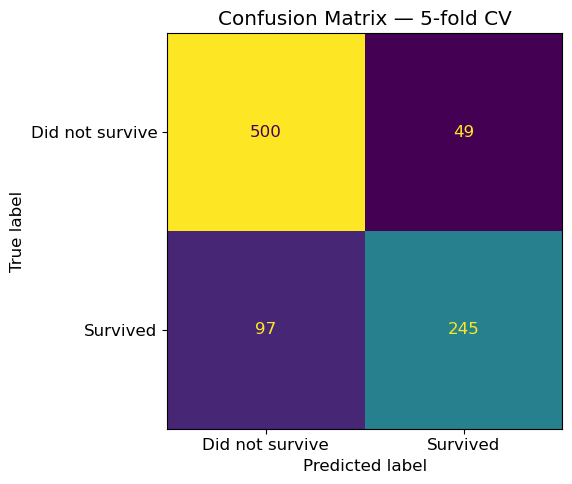

In [15]:
cm = confusion_matrix(y, y_cv_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Did not survive", "Survived"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — 5-fold CV")
plt.tight_layout()
plt.show()

### 8. Feature Importance

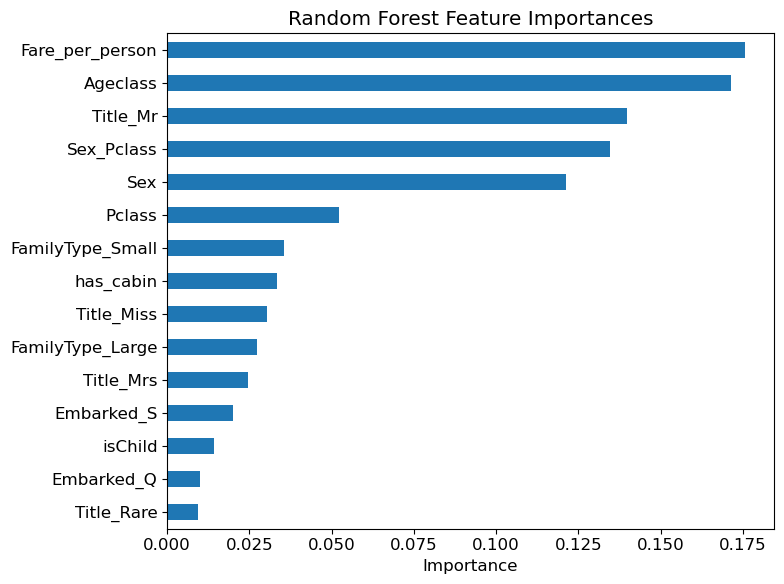

Fare_per_person     0.175718
Ageclass            0.171500
Title_Mr            0.139943
Sex_Pclass          0.134659
Sex                 0.121232
Pclass              0.052364
FamilyType_Small    0.035447
has_cabin           0.033375
Title_Miss          0.030251
FamilyType_Large    0.027349
Title_Mrs           0.024541
Embarked_S          0.019937
isChild             0.014363
Embarked_Q          0.009830
Title_Rare          0.009490
dtype: float64


In [16]:
# Refit on full training data to get stable importances
best_model.fit(X, y)

importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax)
ax.set_title("Random Forest Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

### 9. Submission File

In [17]:
# Predict on the ACTUAL test set (X_test — data the model has never seen)
test_predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived":    test_predictions
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(f"Predicted survivors: {test_predictions.sum()} / {len(test_predictions)}")
submission.head(10)

Saved submission.csv
Predicted survivors: 150 / 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


### 10. Statistical Model Comparison

In [18]:
from scipy import stats

lr_model = LogisticRegression(max_iter=1000)
rf_model = grid_search.best_estimator_

lr_scores = cross_val_score(lr_model, X, y, cv=5, scoring="accuracy")
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")

# Paired t-test — each fold is a paired observation
t_stat, p_value = stats.ttest_rel(rf_scores, lr_scores)

# Calculate the actual percentage of survivors (baseline)
original_mean = train_df["Survived"].mean()
original_std = train_df["Survived"].std()

print("Original            - Mean: {:.4f}, Std: {:.4f}".format(original_mean, original_std))
print("Logistic Regression — Mean: {:.4f}, Std: {:.4f}".format(lr_scores.mean(), lr_scores.std()))
print("Random Forest       — Mean: {:.4f}, Std: {:.4f}".format(rf_scores.mean(), rf_scores.std()))
print()
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    winner = "Random Forest" if rf_scores.mean() > lr_scores.mean() else "Logistic Regression"
    print(f"✅ Difference is statistically significant (p < 0.05) → {winner} wins")
else:
    print("⚠️  Difference is NOT statistically significant (p ≥ 0.05)")
    print("   The models perform equivalently — prefer the simpler one (Logistic Regression)")

Original            - Mean: 0.3838, Std: 0.4866
Logistic Regression — Mean: 0.8271, Std: 0.0132
Random Forest       — Mean: 0.8361, Std: 0.0303

t-statistic : 0.5890
p-value     : 0.5875

⚠️  Difference is NOT statistically significant (p ≥ 0.05)
   The models perform equivalently — prefer the simpler one (Logistic Regression)


## 11. Insight: Why Logistic Regression Works Well Here

Logistic Regression is a **linear classifier** — it fits a weighted sum of features to predict a probability. On this dataset it performs comparably to (or better than) a much more powerful Random Forest. Why?

1. **The survival signal is largely linear.** Being female, being in 1st class, paying a higher fare, and having a title like `Mrs` or `Miss` are all *additive* predictors. There is no complex interaction that requires trees to capture.

2. **I engineered interaction terms explicitly.** `Sex_Pclass` and `Ageclass` are hand-crafted products that encode the most important non-linearities (e.g. being a woman in 3rd class is very different from being a woman in 1st class). By providing these directly, Logistic Regression does not need to "discover" them.

3. **Small dataset, risk of overfitting.** With only ~890 training samples, a high-capacity model like Random Forest can overfit. Logistic Regression's implicit regularisation helps it generalise better in low-data regimes.

4. **Calibrated probabilities.** Logistic Regression produces well-calibrated probability estimates, which is useful if you ever want to threshold at something other than 0.5 or compute expected value.

## 12. Insight: The Role of Sex and Pclass

The two most important raw features in this dataset — and in the real historical event — are `Sex` and `Pclass`. Let's visualise survival rates to understand *why* the model leans on them so heavily.

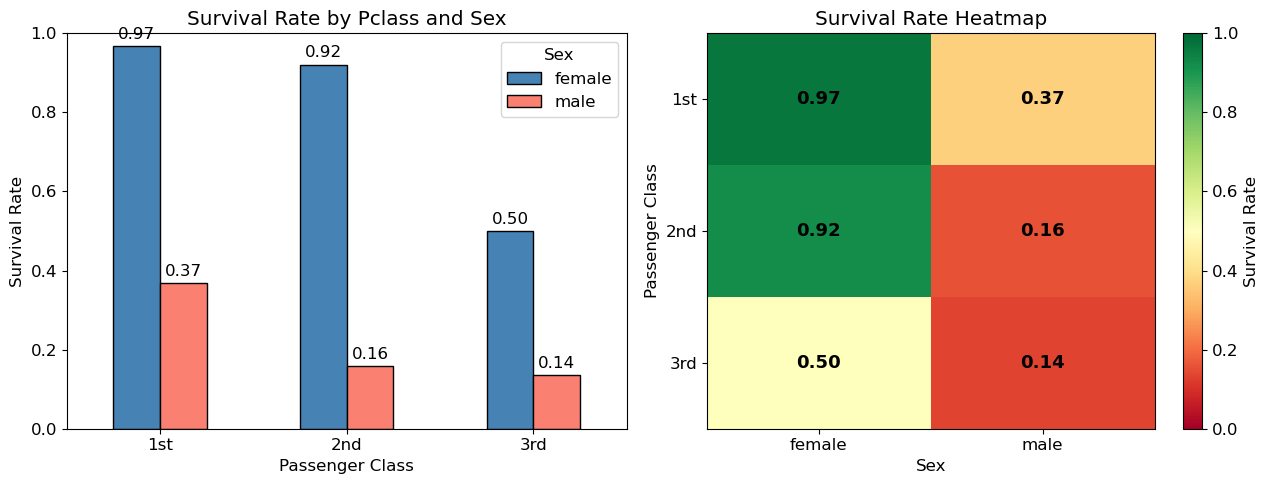


Key takeaways:
• 1st-class women had a survival rate of ~97% — almost all survived.
• 3rd-class men had a survival rate of ~13% — almost none survived.
• The Sex × Pclass interaction spans a ~84 percentage-point range.
• This is why Sex_Pclass is one of the most predictive engineered features.


In [19]:
# Survival rate by Sex × Pclass
pivot = train_df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Grouped bar chart 
pivot.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Survival Rate by Pclass and Sex')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
axes[0].legend(title='Sex')
axes[0].set_ylim(0, 1)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3)

# Right: Heatmap 
im = axes[1].imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(pivot.columns)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['1st', '2nd', '3rd'])
axes[1].set_title('Survival Rate Heatmap')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Passenger Class')
for i in range(3):
    for j in range(2):
        axes[1].text(j, i, f'{pivot.values[i, j]:.2f}',
                     ha='center', va='center', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Survival Rate')

plt.tight_layout()
plt.show()

print('\nKey takeaways:')
print('• 1st-class women had a survival rate of ~97% — almost all survived.')
print('• 3rd-class men had a survival rate of ~13% — almost none survived.')
print('• The Sex × Pclass interaction spans a ~84 percentage-point range.')
print('• This is why Sex_Pclass is one of the most predictive engineered features.')